In [1]:
!pip install ollama

In [2]:
!sudo apt update
!usdo apt install -y pciutils
!sudo apt install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [4,685 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [112 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,175 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,619 kB]
Get:14 https://r2u.stat.i

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Class OllamaModelTester is initialized
Ollama server is started
"documents/model_results.csv" imported successfully
"documents/validation_results.csv" imported successfully


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1618: UserWarning: Note that pos_label (set to 'hallucinated') is ignored when average != 'binary' (got 'weighted'). You may use labels=[pos_label] to specify a single positive class.
  warnings.warn(


"tinyllama" model is pulled successfully!
"gemma2:2b" model is pulled successfully!
"llama3.2:1b" model is pulled successfully!
"smollm2:135m" model is pulled successfully!
Testing model "tinyllama"
Successfully completed testing model "tinyllama"
Testing model "gemma2:2b"
Successfully completed testing model "gemma2:2b"
Testing model "llama3.2:1b"
Successfully completed testing model "llama3.2:1b"
Testing model "smollm2:135m"
Successfully completed testing model "smollm2:135m"
Downloading: 100%|██████████|
   gemma2:2b_faithfulness_score  human_faithfulness_score  \
0                      0.666667                       1.0   

   tinyllama_faithfulness_score  
0                           1.0  


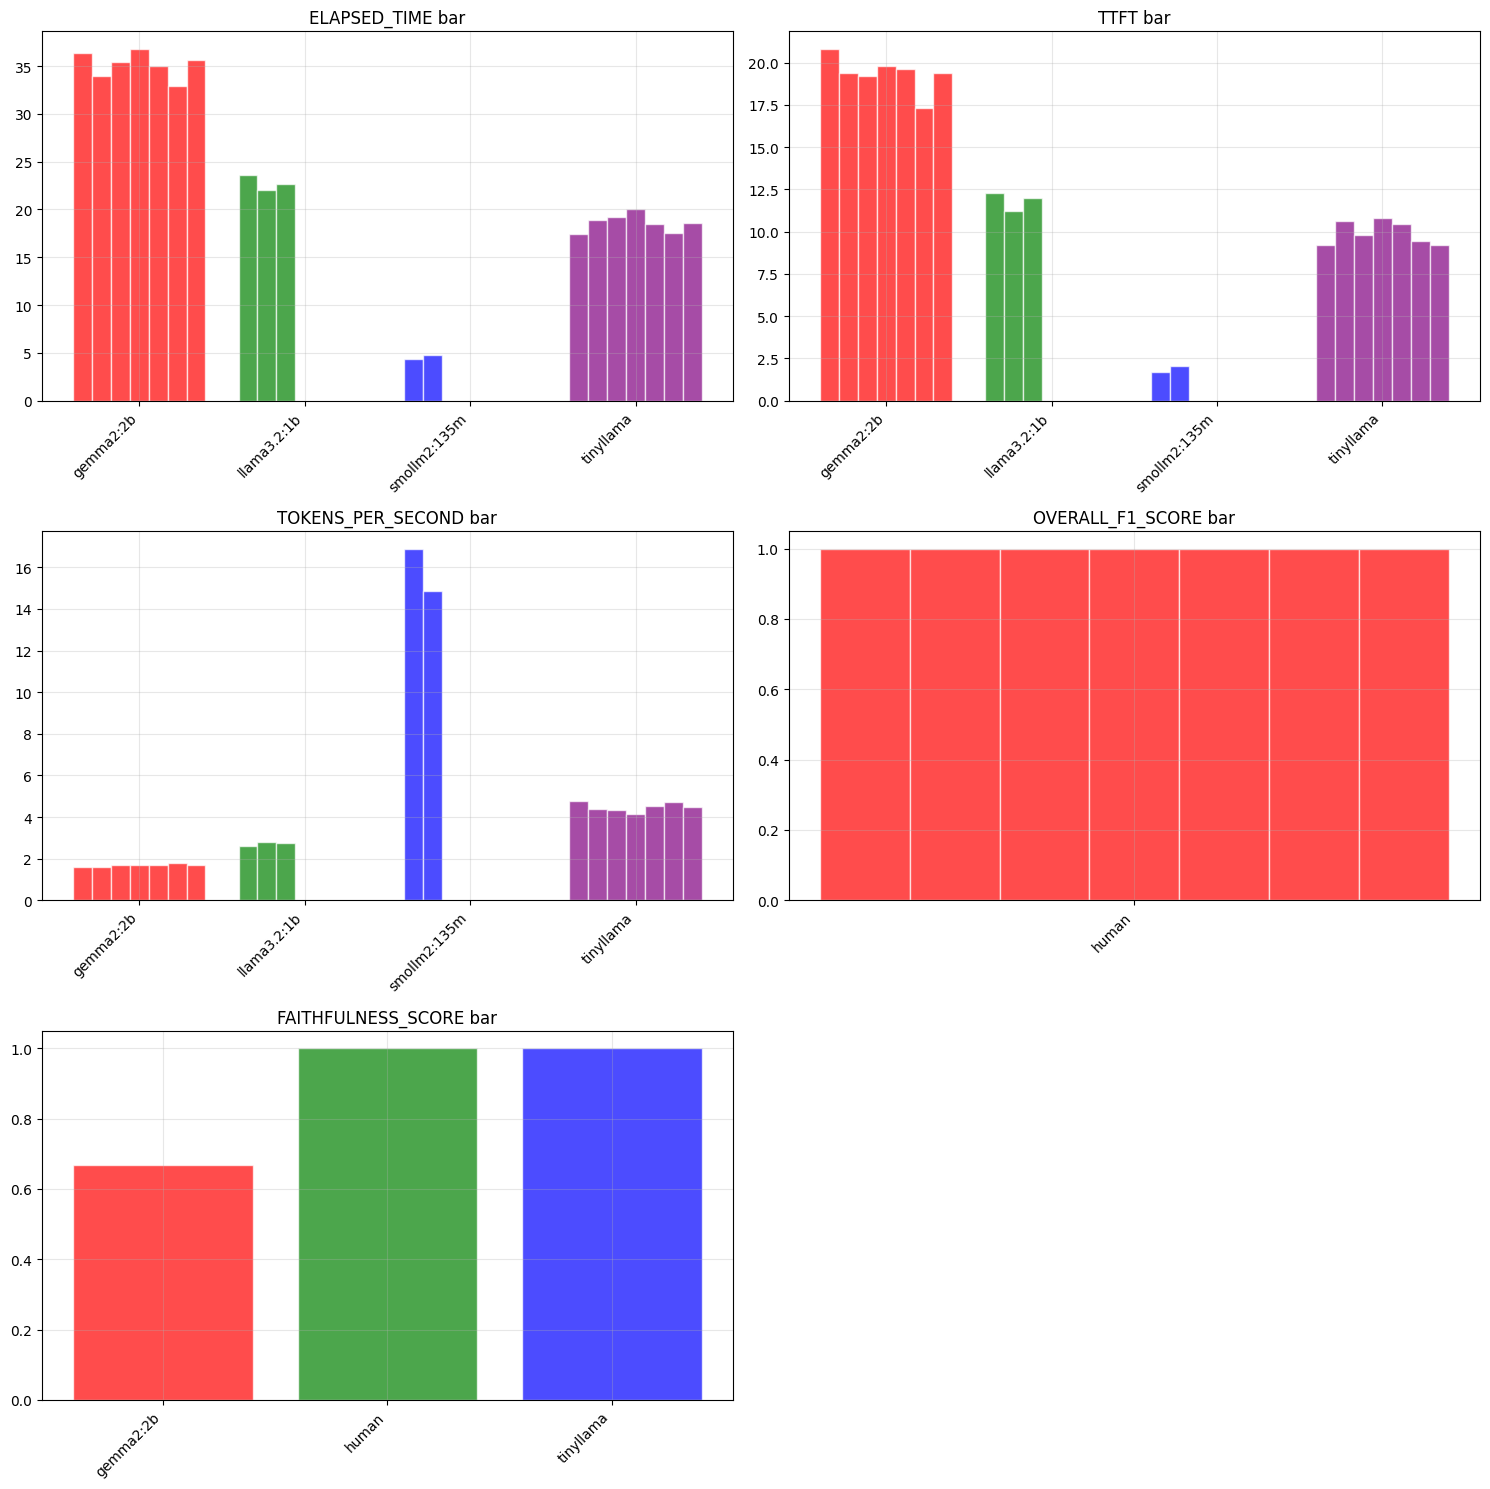

Downloading: 100%|██████████|
   gemma2:2b_faithfulness_score  human_faithfulness_score  \
0                      0.666667                       1.0   

   tinyllama_faithfulness_score  
0                           1.0  


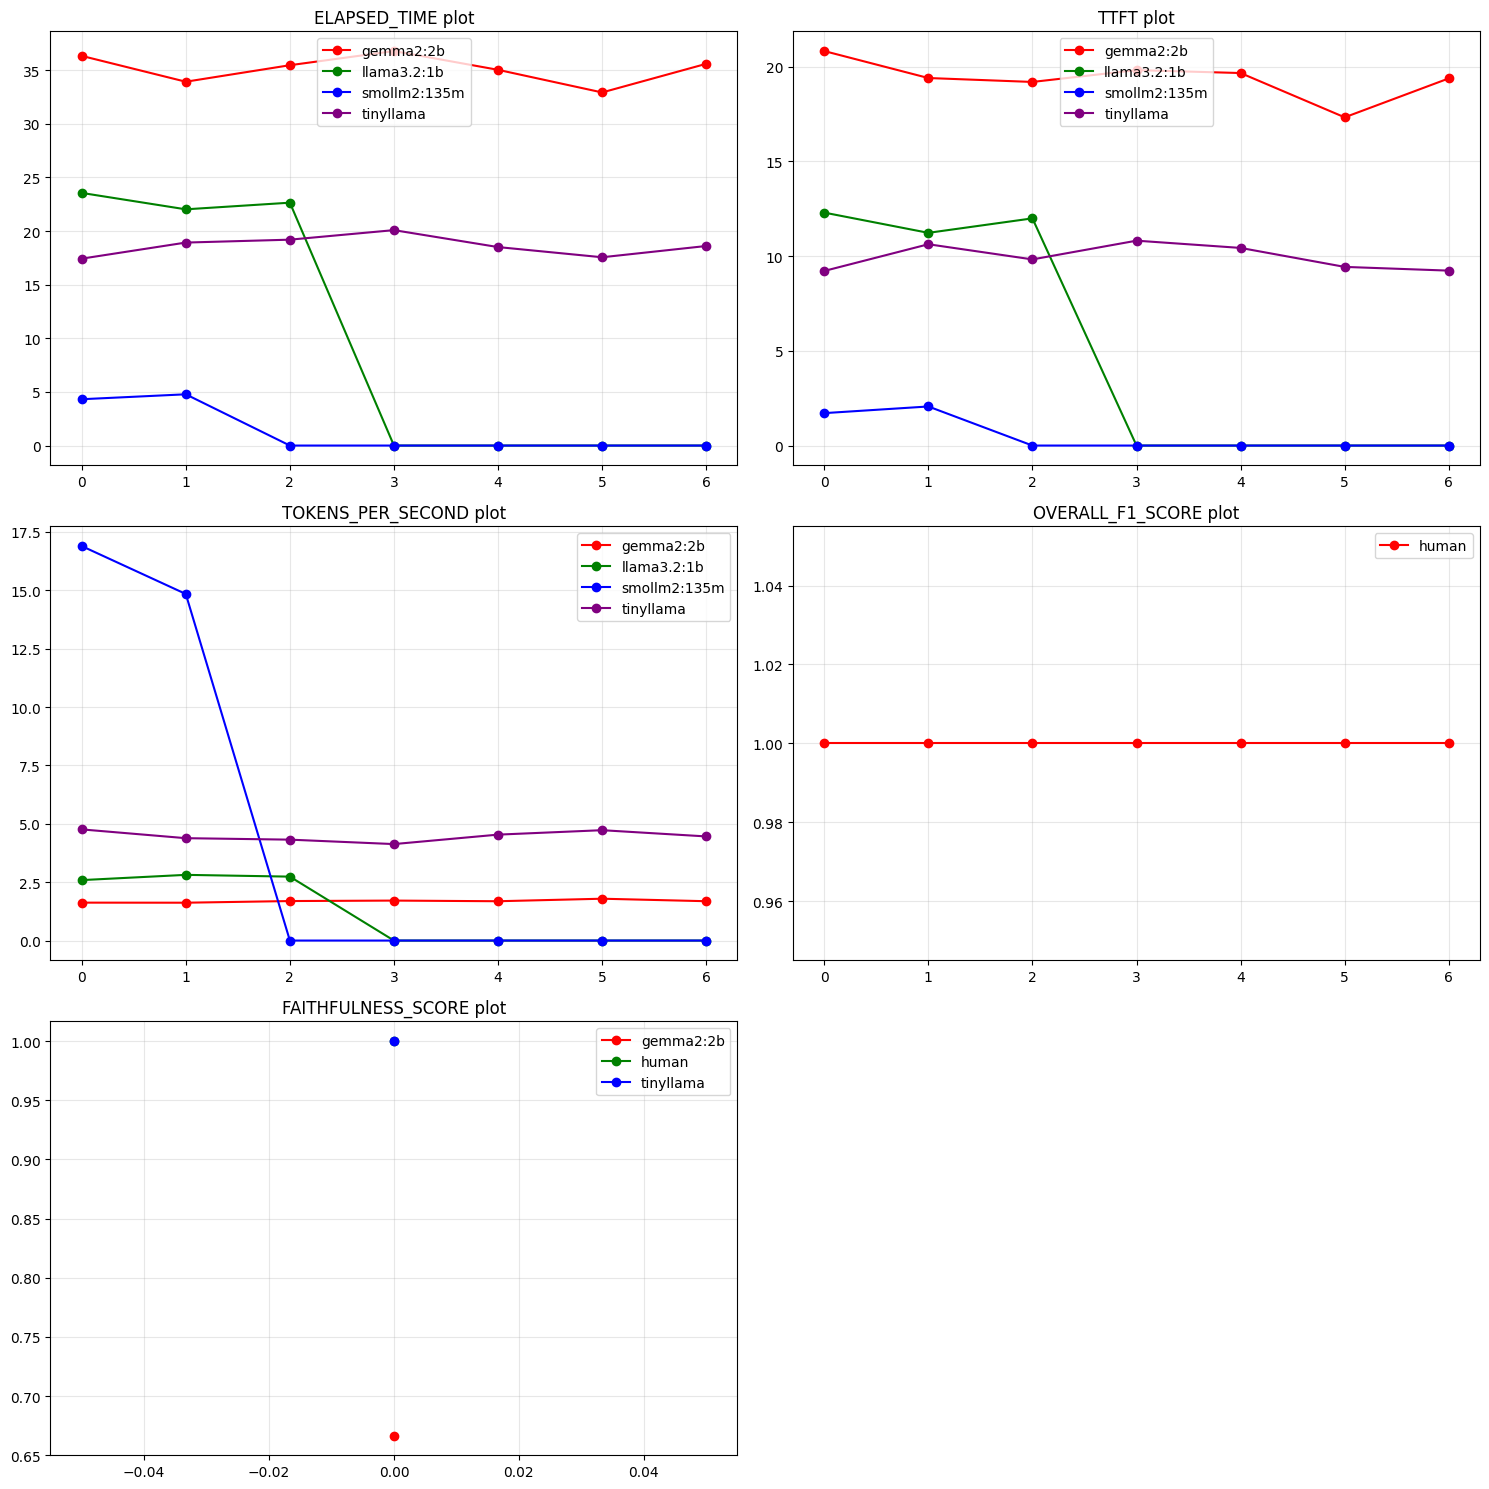

Downloading: 100%|██████████|
   gemma2:2b_faithfulness_score  human_faithfulness_score  \
0                      0.666667                       1.0   

   tinyllama_faithfulness_score  
0                           1.0  


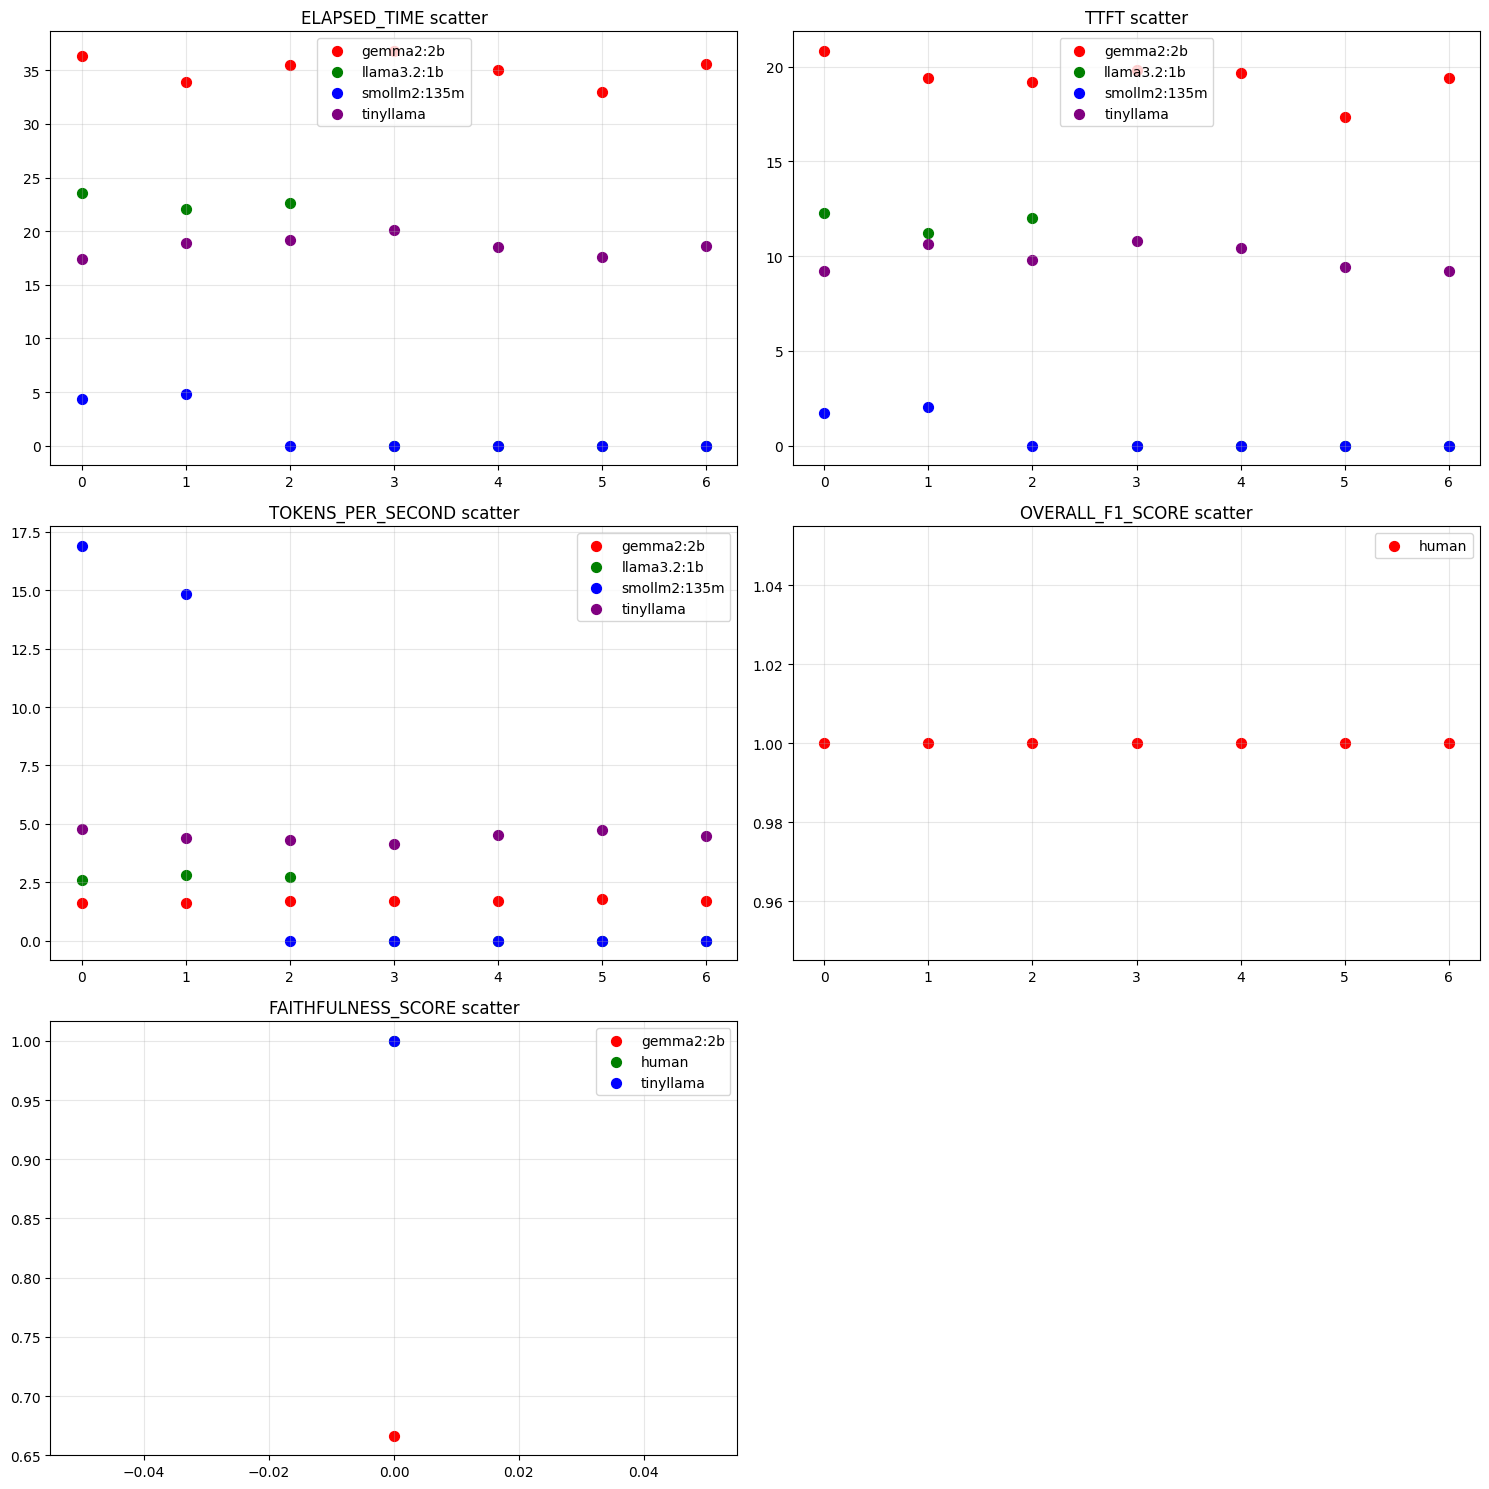

Downloading: 100%|██████████|
   gemma2:2b_faithfulness_score  human_faithfulness_score  \
0                      0.666667                       1.0   

   tinyllama_faithfulness_score  
0                           1.0  


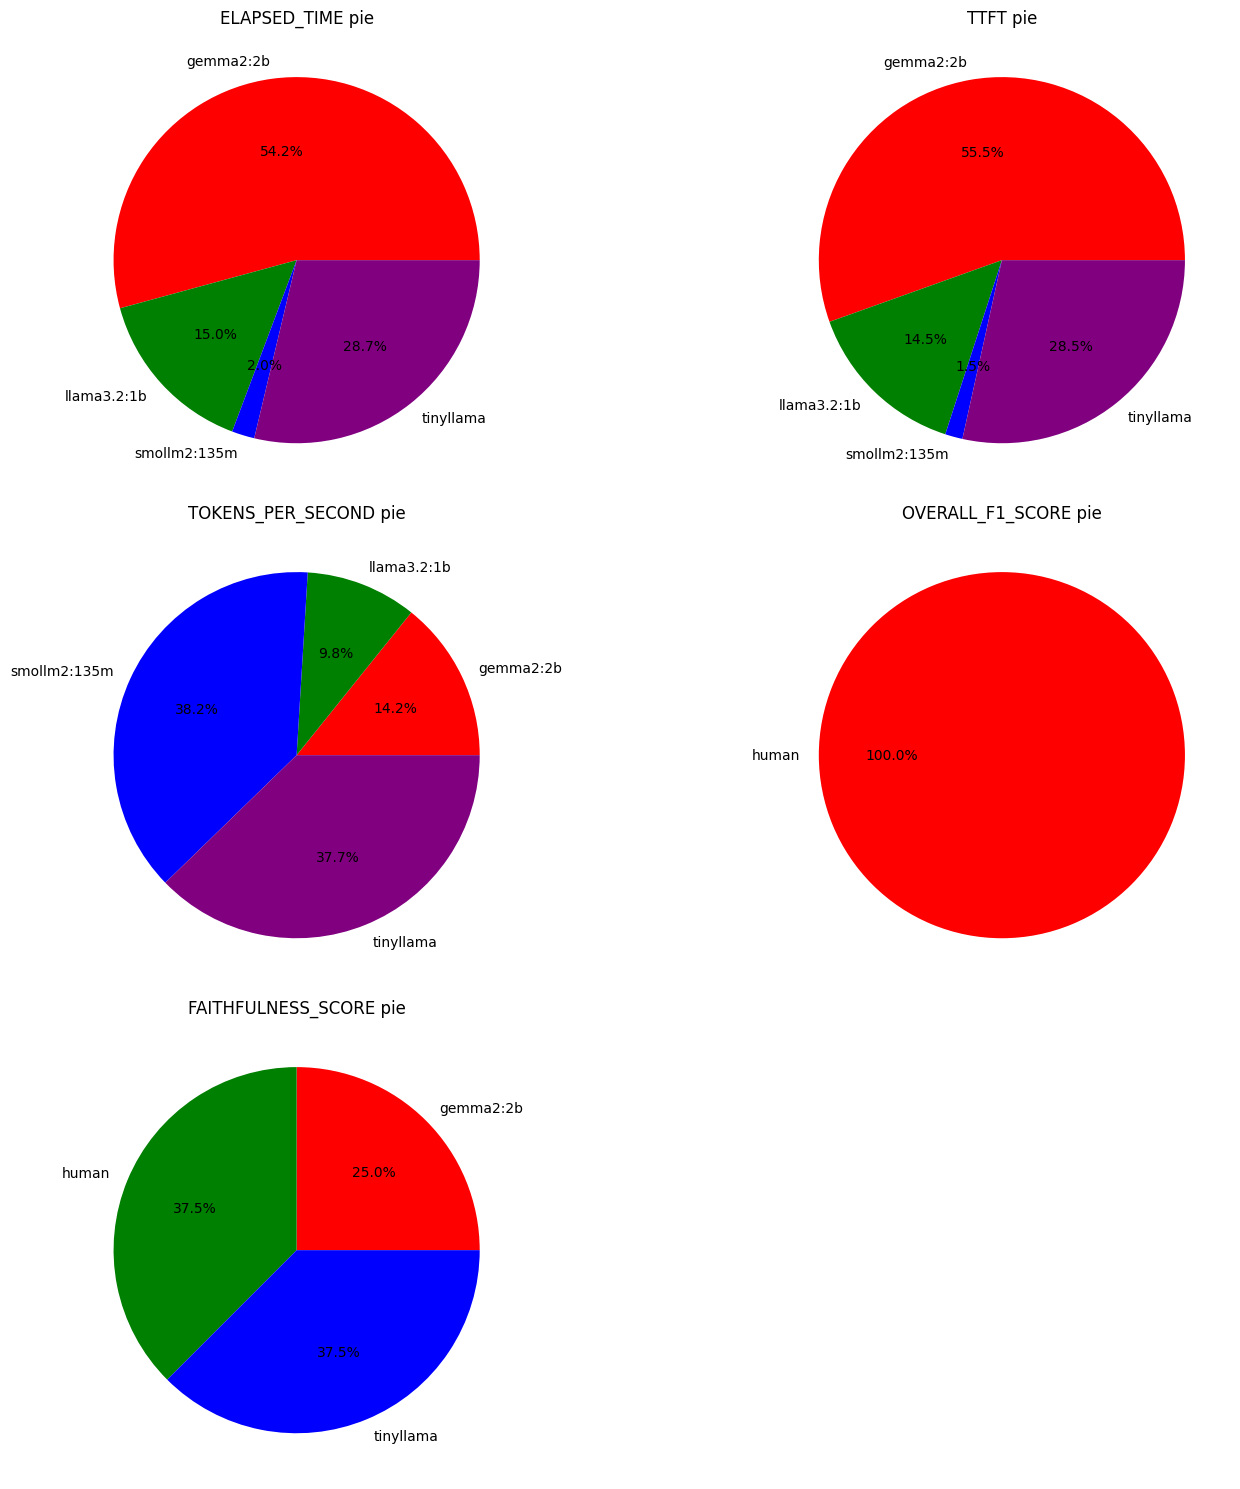

Exported file to "documents/model_results.csv"
Exported file to "documents/validation_results.csv"


100%|██████████| 1/1 [00:00<00:00, 11096.04it/s]


Table "model_results" export is completed


100%|██████████| 1/1 [00:00<00:00, 9915.61it/s]

Table "validation_results" export is completed
Ollama server is terminated


In [15]:
from asyncio.unix_events import subprocess
import time
import ollama
import asyncio
import nest_asyncio
import os
import requests
from transformers import pipeline
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize
import re
from typing import Optional, List, Dict, Any
import torch
import multiprocessing
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
from datetime import datetime
from google.oauth2 import service_account
from google.api_core.exceptions import NotFound
import pandas_gbq

import matplotlib.pyplot as plt
import numpy as np

nest_asyncio.apply()


class ModelVisualizer:
    """
    Meeting 4
    Public class ModelVisualizer to build static charts by given data
    """
    DEFAULT_COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E',
                      '#BC4B51', '#5D576B', '#F4A261', '#264653', '#E76F51']

    @staticmethod
    def __ensure_1d(arr):
        """Ensure array is 1D, flatten if multi-dimensional."""
        if hasattr(arr, 'ndim') and arr.ndim > 1:
            return arr.flatten()
        return arr

    @staticmethod
    def _group_by_model(data, cols, metric):
        """Group columns by model name and aggregate values."""
        model_data = {}
        for c in cols:
            model_name = c.replace(f'_{metric}', '')
            vals = ModelVisualizer.__ensure_1d(data[c].dropna().values)
            if model_name not in model_data:
                model_data[model_name] = []
            model_data[model_name].append(vals)
        return model_data

    @staticmethod
    def visualize_chart(
            plot_type: str = 'bar',
            metrics: List[str] = None,
            colors: Optional[List[str]] = None,
            data: pd.DataFrame = None,
            savefig_path: str = None,
            max_cols_per_row: int = 3,
            **options
    ) -> plt:
        """
        Public method to visualize and save charts.

        Args:
            plot_type (str): Select plot type ('bar', 'plot', 'scatter', 'pie')
            metrics (List[Dict[str, Any]]): Metrics to extract and compare the data
            colors: (Optional[List[Dict[str, Any]]]): List of predefined colors to color the AI model or Human-labelled chart with the data
            data (pd.DataFrame): DataFrame with the data to process
            savefig_path (str): Path to save the figures
            max_cols_per_row (int): Define maximum number of charts per row
            **options: Keyword arguments to accept any number of named (keyword) inputs, packed into a standard dictionary

        Returns:
            plt: Matplotlib Pyplot of the built chart
        """
        if colors is None:
            colors = ModelVisualizer.DEFAULT_COLORS

        # Get unique columns while preserving order
        var_unique_columns = []
        seen = set()
        for item in metrics:
            for col in item['columns']:
                if col not in seen:
                    seen.add(col)
                    var_unique_columns.append(col)

        # Setup subplots
        n_cols = min(max_cols_per_row, len(var_unique_columns))
        n_rows = (len(var_unique_columns) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

        for idx, metric in enumerate(var_unique_columns):
            ax = axes[idx]

            # Get columns for this metric
            cols = [c for c in data.columns if metric in c]

            if not cols:
                ax.set_title(f'{metric.upper()} (No Data)')
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center')
                ax.grid(True, alpha=0.3)
                continue

            model_data = {}
            for c in cols:
                model_name = c.replace(f'_{metric}', '')
                vals = ModelVisualizer.__ensure_1d(data[c].dropna().values)
                if model_name not in model_data:
                    model_data[model_name] = []
                model_data[model_name].append(vals)

            # Create unique names list
            names_list = list(model_data.keys())

            # Aggregate values (take first occurrence)
            values = []
            for model_name in names_list:
                model_vals = model_data[model_name]
                # Take first occurrence (prefer model_results over validation)
                combined_vals = model_vals[0]
                values.append(combined_vals)

            if plot_type == 'bar':
                if values:
                    max_len = max([len(v) for v in values]) if values else 0
                    x = np.arange(len(names_list))
                    width = 0.8 / max_len if max_len > 0 else 0.8

                    for i in range(max_len):
                        vals = [v[i] if i < len(v) else 0 for v in values]
                        if len(vals) == len(x):
                            bar_colors = [colors[j % len(colors)] for j in range(len(vals))]
                            ax.bar(x + i * width, vals, width, color=bar_colors,
                                   alpha=0.7, edgecolor='white', linewidth=1)

                    ax.set_xticks(x + width * (max_len - 1) / 2)
                    ax.set_xticklabels(names_list, rotation=45, ha='right')

            elif plot_type == 'plot':
                for i, name in enumerate(names_list):
                    # Get values for this model
                    model_vals = model_data[name]
                    vals = model_vals[0]  # Take first
                    ax.plot(range(len(vals)), vals, marker='o',
                        label=name, color=colors[i % len(colors)])
                ax.legend()

            elif plot_type == 'scatter':
                for i, name in enumerate(names_list):
                    model_vals = model_data[name]
                    vals = model_vals[0]  # Take first
                    ax.scatter(range(len(vals)), vals,
                             color=colors[i % len(colors)], label=name, s=50)
                ax.legend()

            elif plot_type == 'pie':
                values = []
                for name in names_list:
                    model_vals = model_data[name]
                    val = model_vals[0].sum() if len(model_vals[0]) > 0 else 0
                    values.append(val)

                if values and any(v > 0 for v in values):
                    pie_colors = [colors[i % len(colors)] for i in range(len(names_list))]
                    ax.pie(values, labels=names_list, colors=pie_colors, autopct='%1.1f%%')

            ax.set_title(f'{metric.upper()} {plot_type}')
            ax.grid(True, alpha=0.3)

        # Cleanup figures on the row
        for idx in range(len(var_unique_columns), len(axes)):
            axes[idx].set_visible(False)

        plt.tight_layout()

        if savefig_path:
            save_dir = os.path.dirname(savefig_path)
            if save_dir:
                os.makedirs(save_dir, exist_ok=True)
            var_dpi = options.get('dpi', 300)
            plt.savefig(savefig_path, dpi=var_dpi, bbox_inches='tight')

        plt.show()

        return plt


class OllamaModelTester:

    def __init__(self, host, port, models):
        self.host = host
        self.port = port
        self.models = models if models else []
        self.process = None
        self.model_results = []
        self.validation_results = []
        self.dft_sleep_sec = 10
        self.nli_model = None
        self.key_path = None
        self.credentials = None

    def get_data(self, key):
        return getattr(self, key)

    def set_data(self, key, val):
        setattr(self, key, val)

    def pull_model(self, model_name):
        result = subprocess.run(
            ['ollama', 'pull', model_name],
            capture_output=True,
            text=True
        )
        if (result.returncode == 0):
            print(f'"{model_name}" model is pulled successfully!')
        else:
            print(f'"{model_name}" model pull threw an error')

    def pull_models(self, models):
        models = models if models else self.models
        for model_name in models:
            result = subprocess.run(
                ['ollama', 'pull', model_name],
                capture_output=True,
                text=True
            )
            if (result.returncode == 0):
                print(f'"{model_name}" model is pulled successfully!')
            else:
                print(f'"{model_name}" model pull threw an error')

    def compare_models(self, prompt_text, models, **options):
        var_models = models if models else self.models
        var_options = {
            'temperature': options.get('temperature', 0.1),
            'num_ctx': options.get('num_ctx', 512)
        }
        for model_name in var_models:
            try:
                print(f'Testing model "{model_name}"')

                first_token_received = False
                tokens_received = 0
                token_times = []
                response_text = ''

                ttft_start = time.time()
                start=time.time()

                response_generator = ollama.generate(
                    model=model_name,
                    prompt=prompt_text,
                    options=var_options,

                    stream=True
                )

                for chunk in response_generator:
                    current_time = time.time()
                    tokens_received += 1

                    if (not first_token_received):
                        ttft = current_time - ttft_start
                        first_token_received = True
                        token_times.append(ttft)
                    else:
                        token_times.append(current_time - start)

                    response_text += chunk['response']

                elapsed=time.time() - start

                tokens_per_second = tokens_received / elapsed if elapsed > 0 else 0
                sorted_times = sorted(token_times)
                p50 = sorted_times[len(sorted_times) // 2] if len(sorted_times) > 0 else 0
                p95 = sorted_times[int(len(sorted_times) * 0.95)] if len(sorted_times) > 0 else 0

                model_comparison: Dict[str, Any] = {
                    'model': model_name,
                    'response': response_text,
                    'tokens': len(response_text.split()),
                    'elapsed_time': round(elapsed, 2),
                    'ttft': round(ttft, 3),
                    'tokens_per_second': round(tokens_per_second, 3),
                    'p50_latency': round(p50, 3),
                    'p95_latency': round(p95, 3)
                }

                # Extract hardware and model information
                try:
                    model_info = self.__get_model_info(model_name)
                except:
                    model_info = {
                        'hardware': 'unknown',
                        'quantization': 'unknown',
                        'param_size': 'unknown',
                        'files_size': 'unknown',
                        'context_length': 'unknown'
                    }
                model_comparison.update(model_info)

                calculate_scores = self.__calculate_scores(prompt_text, response_text)
                model_comparison.update(calculate_scores)

                self.model_results.append(model_comparison)
                print(f'Successfully completed testing model "{model_name}"')
            except Exception as e:
                self.model_results.append({
                    'model': model_name,
                    'response': f'"{model_name}" error: {str(e)}',
                    'tokens': 0,
                    'elapsed_time': 0,
                    'ttft': 0,
                    'tokens_per_second': 0,
                    'p50_latency': 0,
                    'p95_latency': 0,
                    'hardware': 'unknown',
                    'quantization': 'unknown',
                    'param_size': 'unknown',
                    'files_size': 'unknown',
                    'context_length': 'unknown'
                })
                print(f'Testing model "{model_name}" threw an error')
        return self.model_results

    def validate_evaluator(self, prompt_text: str = None, generated_text: str = None, human_label: str = None) -> List[Dict[str, Any]]:
        """
        Meeting 2 (Extended)
        Public method: Validate human generated text and label

        Args:
            prompt_text (str): Original text
            generated_text (str): Human generated text
            human_label (str): Text defining that generated_text is faithful or hallucinated
        Returns:
            Dict[str, Any]
        """
        result: Dict[str, Any] = {}
        try:
            calculate_scores = self.__calculate_scores(prompt_text, generated_text)
            predicted = 'hallucinated' if (calculate_scores['is_hallucinated'] == 1.0) else 'faithful'

            human_labels = [human_label]
            predictions = [predicted]

            overall_accuracy = accuracy_score(human_labels, predictions)
            overall_f1_score = f1_score(human_labels, predictions, pos_label='hallucinated', average='weighted')

            result.update({
                'human_label': human_label,
                'predicted': predicted,
                'overall_accuracy': overall_accuracy,
                'overall_f1_score': overall_f1_score
            })

            # Extract hardware and model information
            try:
                model_info = self.__get_model_info()
            except:
                model_info = {
                    'hardware': 'unknown',
                    'quantization': 'unknown',
                    'param_size': 'unknown',
                    'files_size': 'unknown',
                    'context_length': 'unknown'
                }
            result.update(model_info)
            result.update(calculate_scores)
            self.validation_results.append(result)
        except Exception as e:
            print(f'Exception thrown: {str(e)}')
        finally:
            return self.validation_results

    def export_results_to_csv(self) -> None:
        """
        Meeting 3
        Public method to export "model_results" and "validation_results" to CSV in a folder "documents"
        """
        folder_path = 'documents'
        if (not os.path.exists(folder_path)):
            os.makedirs(folder_path)
        files_to_export = ['model_results', 'validation_results']
        for file_name in files_to_export:
            filepath = os.path.join(folder_path, f'{file_name}.csv')
            df = pd.DataFrame(self.get_data(file_name))
            if 'timestamp' not in df.columns:
                df['timestamp'] = datetime.now()
            df.to_csv(filepath, index=False)
            print(f'Exported file to "{filepath}"')

    def import_results_from_csv(self) -> None:
        """
        Meeting 3
        Public method to import "model_results" and "validation_results" from CSV in a folder "documents"
        """
        folder_path = 'documents'
        files_to_import = ['model_results', 'validation_results']
        for file_name in files_to_import:
            filepath = os.path.join(folder_path, f'{file_name}.csv')
            if (os.path.exists(filepath)):
                df = pd.read_csv(filepath)
                model_data = df.to_dict('records')
                self.set_data(file_name, model_data)
                print(f'"{filepath}" imported successfully')
            else:
                print(f'"{filepath}" NOT imported')

    def export_results_to_gqb(self, project_id: str = None, dataset_id: str = None, if_exists: str = 'append') -> bool:
        """
        Meeting 3
        Public method to export "model_results" and "validation_results" to Google BigQuery Dataset

        Args:
            project_id(str): Set project ID in Google Cloud
            dataset_id(str): Set dataset ID in Google BigQuery Dataset
            if_exists(str): Select if you want to "append" or "replace" the new data in the export

        Returns:
            bool: Validation if process is completed successful
        """
        is_exported = False
        if (project_id and dataset_id):
            tables_to_export = ['model_results', 'validation_results']
            try:
                for table_name in tables_to_export:
                    df = pd.DataFrame(self.get_data(table_name))
                    if ('timestamp' not in df.columns):
                        df['timestamp'] = datetime.now()
                    pandas_gbq.to_gbq(
                        df,
                        f'{project_id}.{dataset_id}.{table_name}',
                        project_id = project_id,
                        if_exists = if_exists,
                        credentials = self.credentials,
                        progress_bar=True
                    )
                    is_exported = True
                    print(f'Table "{table_name}" export is completed')
            except Exception as e:
                is_exported = False
                print(f'Exception appeared (export_results_to_gqb): {str(e)}')

        return is_exported

    def import_results_from_gbq(self, project_id: str = None, dataset_id: str = None, limits: int = 1000) -> bool:
        """
        Meeting 3
        Public method to import "model_results" and "validation_results" from Google BigQuery Dataset

        Args:
            project_id(str): Set project ID in Google Cloud
            dataset_id(str): Set dataset ID in Google BigQuery Dataset
            limits(int): Select the maximum limits of results that will be selected from the Google BigQuery Dataset tables

        Returns:
            bool: Validation if process is completed successful
        """
        is_imported = False
        if (project_id and dataset_id):
            tables_to_export = ['model_results', 'validation_results']
            try:
                for table_name in tables_to_export:
                    query = f"""
                    SELECT *
                      FROM `{project_id}.{dataset_id}.{table_name}`
                     LIMIT {limits}
                    """
                    df = pandas_gbq.read_gbq(
                        query,
                        project_id = project_id,
                        credentials = self.credentials
                    )

                    model_data = df.to_dict('records')
                    self.set_data(table_name, model_data)
                    is_imported = True
                    print(f'Table "{table_name}" import is successful')
            except NotFound as e:
                is_imported = False
                print(f'Table "{table_name}" is not found')
            except Exception as e:
                is_imported = False
                print(f'Exception appeared (import_results_from_gbq): {str(e)}')

        return is_imported

    def print_results(self, i_results: List[Dict[str, Any]] = []) -> None:
        var_results = i_results if i_results else self.model_results
        for row in var_results:
            print('')
            [print(f'{k}: {v}') for k, v in row.items()]
            print('')

    def visualize_results(
        self,
        plot_type: str = None,
        metrics: List[Dict[str, Any]] = None,
        colors: Optional[List[Dict[str, Any]]] = None,
        savefig_path: str = None,
        max_cols_per_row: int = 3,
        **options
    ) -> plt:
        """
        Meeting 4
        Public method to visualize internal resutls from self.model_results, self.validation_results and query SQL statements to Google BigQuery Dataset.

        Args:
            plot_type (str): Select plot type ('bar', 'plot', 'scatter', 'pie')
            metrics (List[Dict[str, Any]]): Metrics to extract and compare the data
            colors: (Optional[List[Dict[str, Any]]]): List of predefined colors to color the AI model or Human-labelled chart with the data
            savefig_path (str): Path to save the figures
            max_cols_per_row (int): Define maximum number of charts per row
            **options: Keyword arguments to accept any number of named (keyword) inputs, packed into a standard dictionary

        Returns:
            plt: Matplotlib Pyplot of the chart
        """
        all_dfs = []
        VALID_DATA_SOURCES = ['model_results', 'validation_results']
        for metric in metrics:
            var_data = metric['data']
            var_columns = metric['columns']
            var_self_data = self.get_data(var_data) if var_data in VALID_DATA_SOURCES else []
            columns_to_select = ['model', *var_columns] if var_data == 'model_results' else var_columns
            var_df = pd.DataFrame(var_self_data)[columns_to_select] if var_data in VALID_DATA_SOURCES else pd.DataFrame()

            if (var_data == 'model_results'):
                var_df['row_num'] = var_df.groupby('model').cumcount()
                pivoted = var_df.pivot(index='row_num', columns='model', values=var_columns)
                pivoted.columns = [f'{model}_{col}' for col, model in pivoted.columns]
                var_df = pivoted.fillna(0).reset_index(drop=True)
                all_dfs.append(var_df)
            elif (var_data == 'validation_results'):
                var_df.columns = [f'human_{col}' for col in var_df.columns]
                all_dfs.append(var_df)
            elif (var_data == 'sql'):
                try:
                    var_project_id = metric['project_id']
                    query = metric['sql']
                    var_df = pandas_gbq.read_gbq(
                        query,
                        project_id = var_project_id,
                        credentials = self.credentials
                    )
                    var_df['row_num'] = var_df.groupby('model').cumcount()
                    pivoted = var_df.pivot(index='row_num', columns='model', values=var_columns)
                    pivoted.columns = [f'{model}_{col}' for col, model in pivoted.columns]
                    var_df = pivoted.fillna(0).reset_index(drop=True)

                    # print(var_df)
                    all_dfs.append(var_df)
                except NotFound as e:
                    print(f'Exception NotFound: {str(e)}')
                except Exception as e:
                    print(f'Exception: {str(e)}')

        final_df = pd.concat(all_dfs, axis=1)

        fig = ModelVisualizer.visualize_chart(
            plot_type = plot_type,
            metrics = metrics,
            colors = colors,
            data = final_df,
            savefig_path = savefig_path,
            max_cols_per_row = max_cols_per_row,
            options = options
        )
        return fig

    def __initialization(self) -> None:
        os.environ['OLLAMA_HOST'] = f'{self.host}:{self.port}'

        try:
            nltk.data.find('tokenizers/punkt_tab/english')
        except LookupError:
            nltk.download('punkt_tab')
            nltk.download('punkt')
            nltk.download('averaged_perceptron_tagger_eng')

        self.nli_model = pipeline('text-classification',
            model='cross-encoder/nli-deberta-v3-base',
            device=0
        )

        folder_path = 'credentials'
        if (os.path.exists(folder_path)):
            files = os.listdir(folder_path)
            json_files = [f for f in files if f.endswith('.json')]
            self.key_path = f'{folder_path}/{json_files[0]}'
        try:
            self.credentials = service_account.Credentials.from_service_account_file(
                self.key_path,
                scopes = ['https://www.googleapis.com/auth/cloud-platform']
            )
        except Exception as e:
            print(f'Credentials to Google Oauth2 are not set: {str(e)}')
        print('Class OllamaModelTester is initialized')

    def __start_server(self) -> 'OllamaModelTester':
        self.process = subprocess.Popen(
            ['ollama', 'serve'],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            env=os.environ
        )
        time.sleep(self.dft_sleep_sec)
        result = subprocess.run(
            ['curl', '-s', f'http://{self.host}:{self.port}/api/tags'],
            capture_output=True,
            text=True
        )
        if (result.returncode == 0):
            print('Ollama server is started')
        else:
            print('Ollama server is NOT started')

    def __stop_server(self) -> None:
        self.process.terminate()
        self.process.wait()
        print('Ollama server is terminated')


    def __clean_text(self, text):
        """
        Meeting 2
        Private method: Preprocess text for tokenization

        Args:
            text(str): Text to preprocess

        Returns:
            str: Preprocessed text
        """
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        text = ' '.join(text.split())
        return text

    def __calculate_scores(self, reference_text, generated_text):
        """
        Meeting 2
        Private method: Calculate multiple BLUE score variants

        Args:
            reference_text(str): Text passed from main
            generated_text(str): Text generated from AI agent

        Returns:
            Dict[str, float]

        """
        dict_scores = {
            'total': 0.0,
            'factual': 0.0,
            'contradictions': 0.0,
            'neutral': 0.0,
            'confidence': 0.0,
            'is_hallucinated': 0.0,
            'hallucination_severity': 0.0,
            'faithfulness_score': 0.0,
            'bleu_1': 0.0,
            'bleu_2': 0.0,
            'bleu_3': 0.0,
            'bleu_4': 0.0,
            'bleu_avg': 0.0,
            'bleu_smoothing_method0': 0.0,
            'bleu_smoothing_method1': 0.0,
            'bleu_smoothing_method2': 0.0,
            'bleu_smoothing_method3': 0.0,
            'bleu_smoothing_method4': 0.0,
            'bleu_smoothing_method5': 0.0,
            'bleu_smoothing_method6': 0.0,
            'bleu_smoothing_method7': 0.0
        }
        try:
            if (not generated_text or len(generated_text.strip()) == 0):
                return dict_scores

            cleaned_ref = self.__clean_text(reference_text)
            cleaned_gen = self.__clean_text(generated_text)

            reference_tokens = word_tokenize(cleaned_ref)
            generated_tokens = word_tokenize(cleaned_gen)

            if (not reference_tokens or not generated_tokens):
                return dict_scores

            sentences = nltk.sent_tokenize(generated_text)
            if not sentences:
                return dict_scores

            result_scores = []
            for sentence in sentences:
                pred = self.nli_model(f'{reference_text} </s> {sentence}')
                label = (pred[0]['label']).upper()
                score = pred[0]['score']

                result_scores.append({
                    'sentence': sentence,
                    'label': label,
                    'confidence': score
                })

            dict_scores['total'] = len(result_scores)
            dict_scores['factual'] = sum(1 for r in result_scores if r['label'] == 'ENTAILMENT') / len(result_scores)
            dict_scores['contradictions'] = sum(1 for r in result_scores if r['label'] == 'CONTRADICTION') / len(result_scores)
            dict_scores['neutral'] = sum(1 for r in result_scores if r['label'] == 'NEUTRAL') / len(result_scores)
            dict_scores['confidence'] = sum(r['confidence'] for r in result_scores) / len(result_scores)

            dict_scores['is_hallucinated'] = 1.0 if (dict_scores['contradictions'] > 0 or dict_scores['neutral'] > 0.3) else 0
            dict_scores['hallucination_severity'] = (dict_scores['contradictions'] * 1.0) + (dict_scores['neutral'] * 0.5)
            dict_scores['faithfulness_score'] = dict_scores['factual'] - (dict_scores['contradictions'] * 0.5)

            # Calculating BLEU scores
            smoothing = SmoothingFunction()
            var_weights = (0.25, 0.25, 0.25, 0.25)

            dict_scores['bleu_1'] = sentence_bleu([reference_tokens], generated_tokens, weights=(1.0, 0.0, 0.0, 0.0), smoothing_function=smoothing.method1)
            dict_scores['bleu_2'] = sentence_bleu([reference_tokens], generated_tokens, weights=(0.5, 0.5, 0.0, 0.0), smoothing_function=smoothing.method1)
            dict_scores['bleu_3'] = sentence_bleu([reference_tokens], generated_tokens, weights=(0.33, 0.33, 0.33, 0.0), smoothing_function=smoothing.method1)
            dict_scores['bleu_4'] = sentence_bleu([reference_tokens], generated_tokens, weights=(var_weights), smoothing_function=smoothing.method1)
            dict_scores['bleu_avg'] = sum([
                dict_scores['bleu_1'],
                dict_scores['bleu_2'],
                dict_scores['bleu_3'],
                dict_scores['bleu_4']
            ]) / 4.0

            # Calculating smoothing methods
            dict_scores['bleu_smoothing_method0'] = sentence_bleu([reference_tokens], generated_tokens, weights=var_weights, smoothing_function=smoothing.method0)
            dict_scores['bleu_smoothing_method1'] = sentence_bleu([reference_tokens], generated_tokens, weights=var_weights, smoothing_function=smoothing.method1)
            dict_scores['bleu_smoothing_method2'] = sentence_bleu([reference_tokens], generated_tokens, weights=var_weights, smoothing_function=smoothing.method2)
            dict_scores['bleu_smoothing_method3'] = sentence_bleu([reference_tokens], generated_tokens, weights=var_weights, smoothing_function=smoothing.method3)
            dict_scores['bleu_smoothing_method4'] = sentence_bleu([reference_tokens], generated_tokens, weights=var_weights, smoothing_function=smoothing.method4)
            dict_scores['bleu_smoothing_method5'] = sentence_bleu([reference_tokens], generated_tokens, weights=var_weights, smoothing_function=smoothing.method5)
            dict_scores['bleu_smoothing_method6'] = sentence_bleu([reference_tokens], generated_tokens, weights=var_weights, smoothing_function=smoothing.method6)
            dict_scores['bleu_smoothing_method7'] = sentence_bleu([reference_tokens], generated_tokens, weights=var_weights, smoothing_function=smoothing.method7)

            return dict_scores
        except Exception as e:
            print(f'Error appeared: {str(e)}')
            return dict_scores

    def __get_model_info(self, model_name: str = None) -> Dict[str, Any]:
        """
        Meeting 2 (Extended)
        Private method to extract hardware and model information

        Args:
            model_name (str): Model name

        Returns:
            Dict[str, Any]
        """
        info = {
            'hardware': 'unknown',
            'quantization': 'unknown',
            'param_size': 'unknown',
            'files_size': 'unknown',
            'context_length': 'unknown'
        }
        try:
            if (torch.cuda.is_available()):
                gpu_name = torch.cuda.get_device_name(0)
                info['hardware'] = f'GPU: {gpu_name}'
            else:
                cpu_count = multiprocessing.cpu_count()
                info['hardware'] = f'CPU: {cpu_count} cores'

            if (model_name):
                response = requests.get(f'http://{self.host}:{self.port}/api/tags')
                if (response.status_code == 200):
                    data = response.json()
                    models = data.get('models', [])
                    model = [model for model in models if model_name in model['name']]
                    if model:
                        model = model[0]

                        info['quantization'] = model['details']['quantization_level']
                        info['param_size'] = model['details']['parameter_size']
                        info['files_size'] = f'{round(model['size'] / (1024 ** 3), 3)} GB'
                        info['context_length'] = model['details']['context_length']
        except Exception as e:
            print(f'Exception thrown: {str(e)}')
        finally:
            return info

    def __enter__(self):
        self.__initialization()
        self.__start_server()
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.__stop_server()

if (__name__ == '__main__'):
    i_models = ['tinyllama', 'gemma2:2b', 'llama3.2:1b', 'smollm2:135m']
    i_prompt_text = """Summarize this text

Intel Corp. raised $20 billion in an upsized share sale, a third more than it was targeting when it announced the deal Monday morning.

The chipmaker priced the offering at $95 per share, according to a company statement. That represents a discount of 6.5% to Friday’s closing price, according to Bloomberg calculations. The share sale drew more than $100 billion in demand, people familiar with the matter said.
"""

    i_generated_text = """Intel Corp. raised $20 billion in an upsized share sale, a third more than it was targeting when it announced the deal Monday morning"""
    i_human_label = 'faithful' # faithful or hallucinated

    i_metrics = [{
        'data': 'model_results',
        'columns': ['elapsed_time', 'ttft', 'tokens_per_second']
    }, {
        'data': 'validation_results',
        'columns': ['overall_f1_score']
    }, {
        'data': 'sql',
        'columns': ['faithfulness_score'],
        'project_id': 'llm-practical-experiment',
        'dataset_id': 'llm_model_evaluation',
        'sql': """
WITH models AS (
  SELECT mr.model AS `model`
       , mr.faithfulness_score AS `faithfulness_score`
    FROM `llm-practical-experiment.llm_model_evaluation.model_results` AS mr
   LIMIT 1000
),
validations AS (
  SELECT 'human' AS `model`
       , vr.faithfulness_score AS `faithfulness_score`
    FROM `llm-practical-experiment.llm_model_evaluation.validation_results` AS vr
   LIMIT 1000
)
SELECT m.`model`
     , m.`faithfulness_score`
  FROM models AS m
 UNION ALL
SELECT v.`model`
     , v.`faithfulness_score`
  FROM validations AS v
        """
    }]
    i_colors = ['red', 'green', 'blue', 'purple']

    with OllamaModelTester(host='127.0.0.1', port=11434, models=i_models) as om_tester:
        om_tester.import_results_from_csv()
        """
        Create a IAM service account, export the Key as JSON, upload it in folder "credentials" and
        create a Google BigQuery Dataset to use the import export module of Google BigQuery.
        """
        # om_tester.import_results_from_gbq('llm-practical-experiment', 'llm_model_evaluation')

        var_validate_elevator = om_tester.validate_evaluator(
            prompt_text=i_prompt_text,
            generated_text=i_generated_text,
            human_label=i_human_label
        )
        # om_tester.print_results(var_validate_elevator)

        om_tester.pull_models(models=None)
        om_tester.compare_models(prompt_text=i_prompt_text, models=None)
        # om_tester.print_results()

        om_tester.visualize_results(plot_type='bar', metrics=i_metrics, colors=i_colors, savefig_path=f'charts/bar_chart.png', max_cols_per_row=2)
        om_tester.visualize_results(plot_type='plot', metrics=i_metrics, colors=i_colors, savefig_path=f'charts/plot_chart.png', max_cols_per_row=2)
        om_tester.visualize_results(plot_type='scatter', metrics=i_metrics, colors=i_colors, savefig_path=f'charts/scatter_chart.png', max_cols_per_row=2)
        om_tester.visualize_results(plot_type='pie', metrics=i_metrics, colors=i_colors, savefig_path=f'charts/pie_chart.png', max_cols_per_row=2)

        om_tester.export_results_to_csv()
        # om_tester.export_results_to_gqb('llm-practical-experiment', 'llm_model_evaluation', 'replace')
